In [1]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns

In [30]:
df = pd.read_csv('CC GENERAL.csv')

In [31]:
df.head()

,CUST_ID,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
0,C10001,40.900749,0.818182,95.40,0.00,95.4,0.000000,0.166667,0.000000,0.083333,0.000000,0,2,1000.0,201.802084,139.509787,0.000000,12
1,C10002,3202.467416,0.909091,0.00,0.00,0.0,6442.945483,0.000000,0.000000,0.000000,0.250000,4,0,7000.0,4103.032597,1072.340217,0.222222,12
2,C10003,2495.148862,1.000000,773.17,773.17,0.0,0.000000,1.000000,1.000000,0.000000,0.000000,0,12,7500.0,622.066742,627.284787,0.000000,12
3,C10004,1666.670542,0.636364,1499.00,1499.00,0.0,205.788017,0.083333,0.083333,0.000000,0.083333,1,1,7500.0,0.000000,NaN,0.000000,12
4,C10005,817.714335,1.000000,16.00,16.00,0.0,0.000000,0.083333,0.083333,0.000000,0.000000,0,1,1200.0,678.334763,244.791237,0.000000,12


In [32]:
df.drop(['CUST_ID'], axis = 1, inplace = True)

In [22]:
df.duplicated().sum()

0

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8950 entries, 0 to 8949
Data columns (total 17 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   BALANCE                           8950 non-null   float64
 1   BALANCE_FREQUENCY                 8950 non-null   float64
 2   PURCHASES                         8950 non-null   float64
 3   ONEOFF_PURCHASES                  8950 non-null   float64
 4   INSTALLMENTS_PURCHASES            8950 non-null   float64
 5   CASH_ADVANCE                      8950 non-null   float64
 6   PURCHASES_FREQUENCY               8950 non-null   float64
 7   ONEOFF_PURCHASES_FREQUENCY        8950 non-null   float64
 8   PURCHASES_INSTALLMENTS_FREQUENCY  8950 non-null   float64
 9   CASH_ADVANCE_FREQUENCY            8950 non-null   float64
 10  CASH_ADVANCE_TRX                  8950 non-null   int64  
 11  PURCHASES_TRX                     8950 non-null   int64  
 12  CREDIT

In [7]:
df.isnull().sum()

BALANCE                               0
BALANCE_FREQUENCY                     0
PURCHASES                             0
ONEOFF_PURCHASES                      0
INSTALLMENTS_PURCHASES                0
CASH_ADVANCE                          0
PURCHASES_FREQUENCY                   0
ONEOFF_PURCHASES_FREQUENCY            0
PURCHASES_INSTALLMENTS_FREQUENCY      0
CASH_ADVANCE_FREQUENCY                0
CASH_ADVANCE_TRX                      0
PURCHASES_TRX                         0
CREDIT_LIMIT                          1
PAYMENTS                              0
MINIMUM_PAYMENTS                    313
PRC_FULL_PAYMENT                      0
TENURE                                0
dtype: int64

In [33]:
df.dropna(inplace = True)

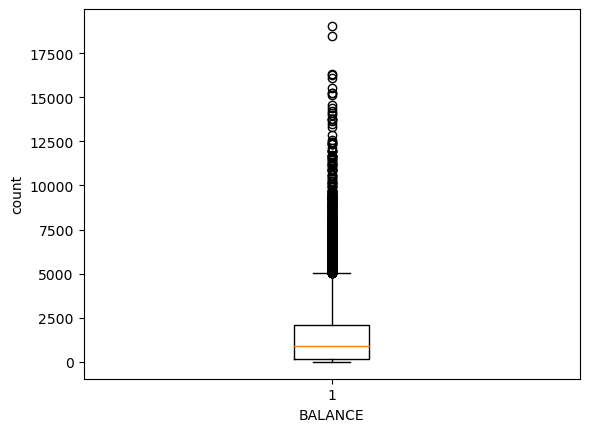

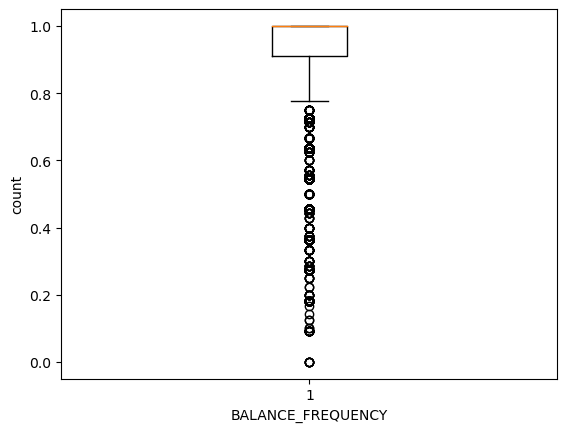

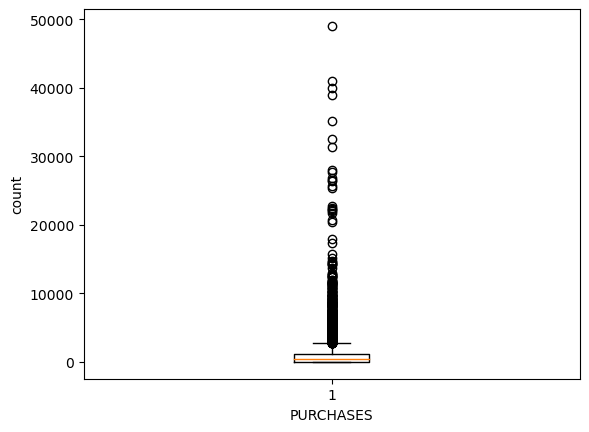

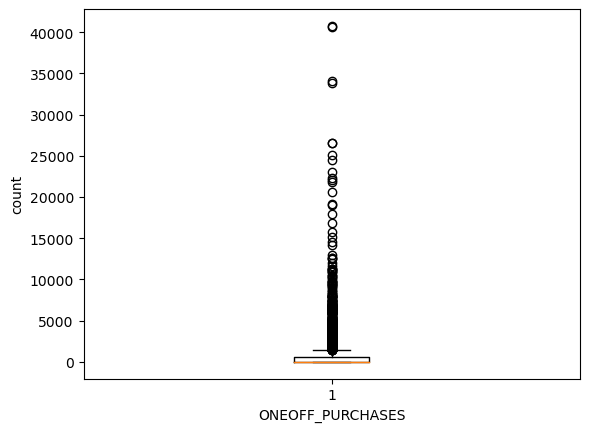

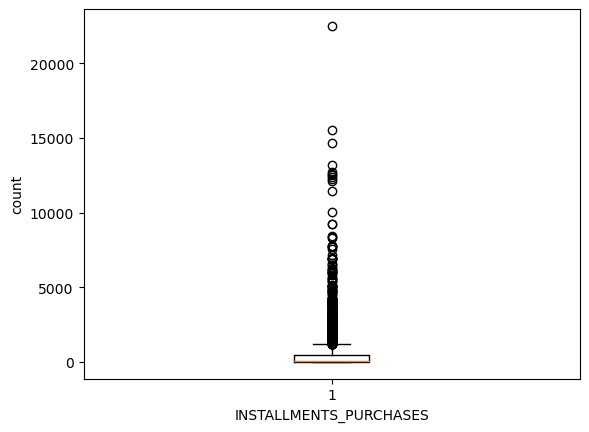

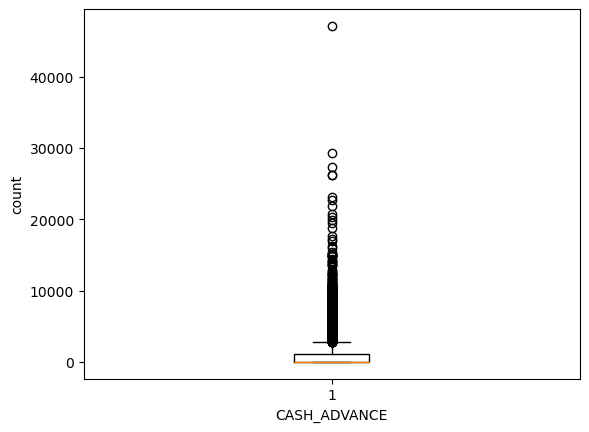

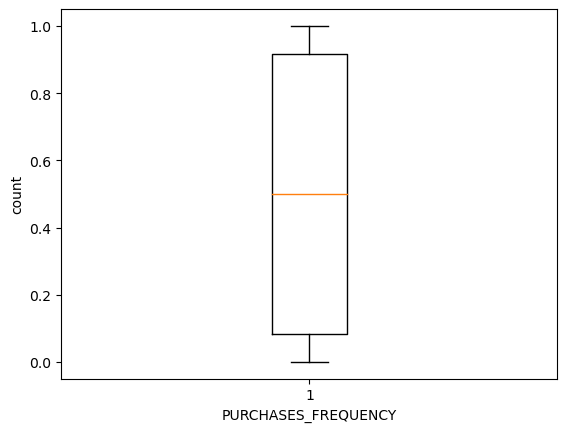

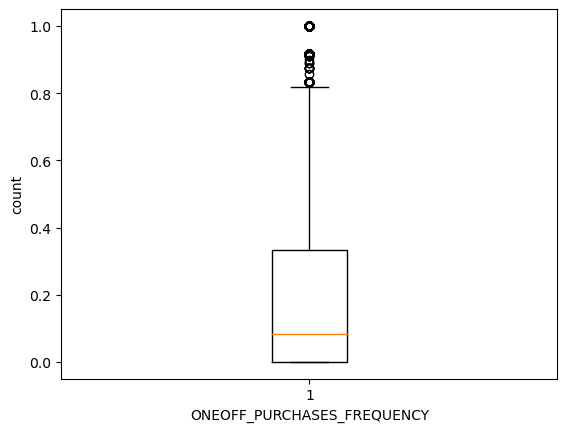

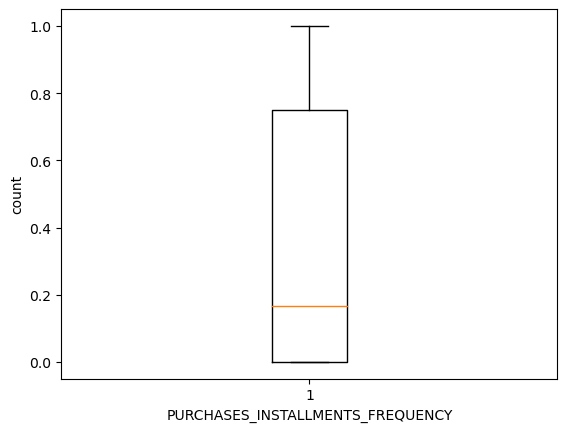

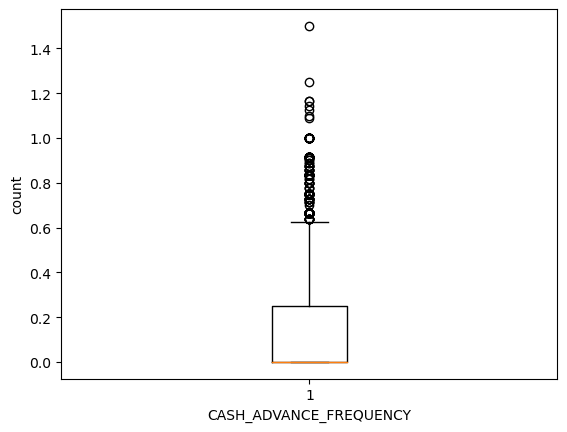

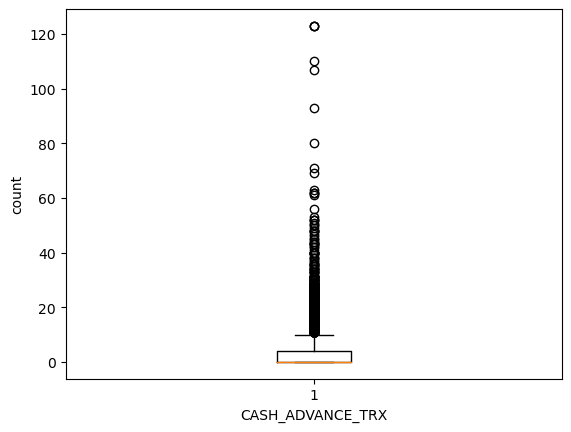

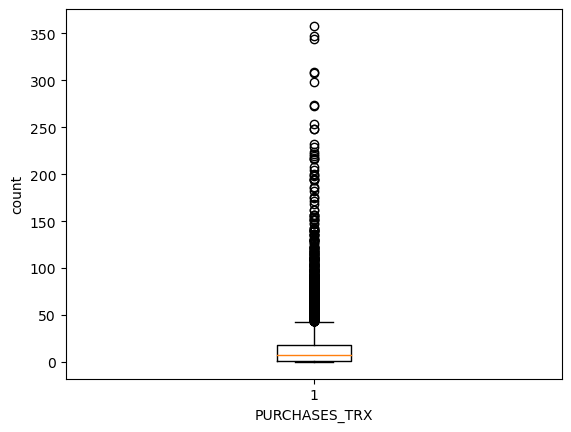

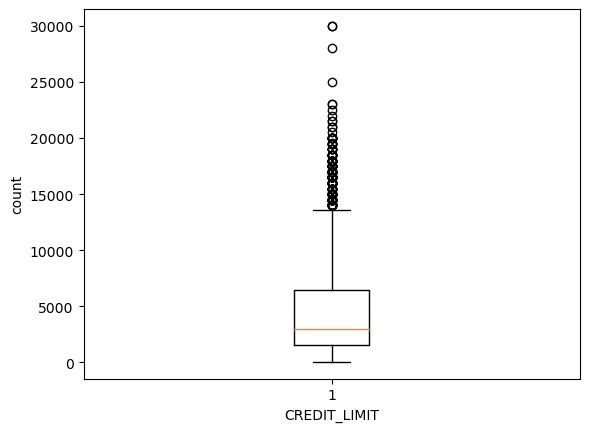

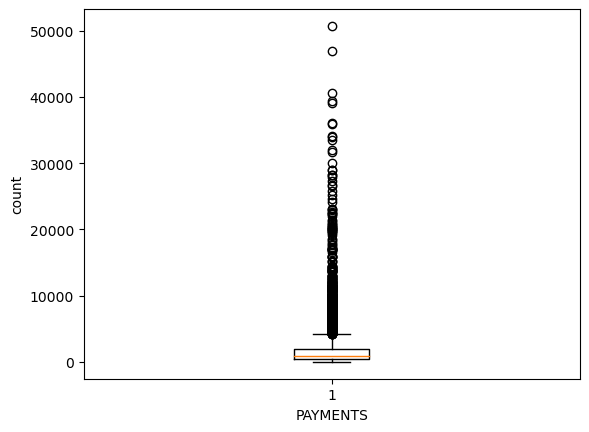

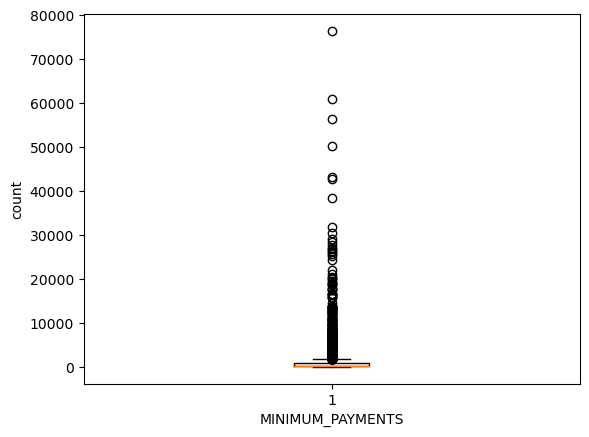

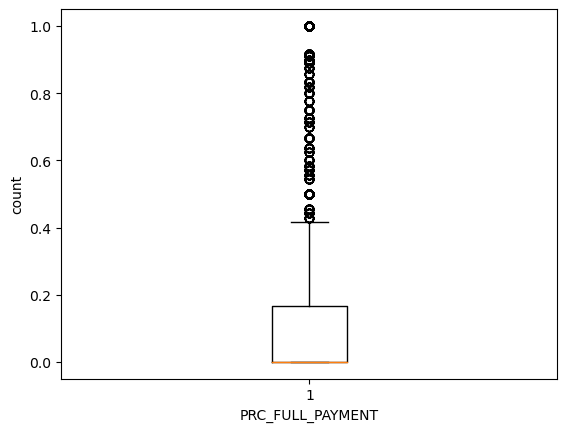

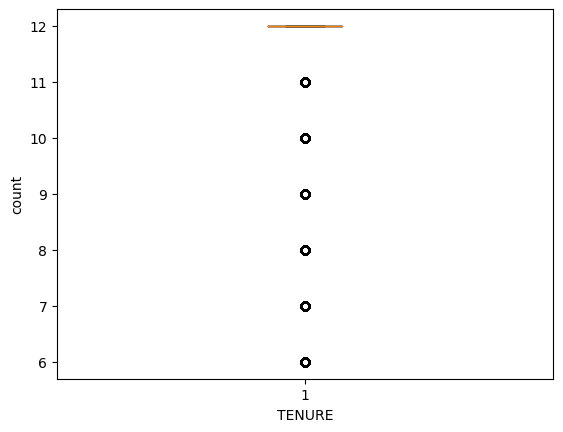

In [34]:
for i in df.columns:
    plt.boxplot(df[i])
    plt.xlabel(i)
    plt.ylabel('count')
    plt.show()

In [35]:
df.shape

(8636, 17)

In [36]:
col = ['BALANCE', 'BALANCE_FREQUENCY', 'PURCHASES', 'ONEOFF_PURCHASES',
       'INSTALLMENTS_PURCHASES', 'CASH_ADVANCE',
       'ONEOFF_PURCHASES_FREQUENCY',
       'CASH_ADVANCE_FREQUENCY', 'CASH_ADVANCE_TRX', 'PURCHASES_TRX',
       'CREDIT_LIMIT', 'PAYMENTS', 'MINIMUM_PAYMENTS', 'PRC_FULL_PAYMENT',
       'TENURE']

In [25]:
"""for i in col:
    Q1 = df[i].quantile(0.25)
    Q3 = df[i].quantile(0.75)
    IQR = Q3 - Q1
    df = df[(df[i] >= Q1 - 1.5*IQR) & (df[i] <= Q3 + 1.5*IQR)]

In [26]:
df.shape

(2035, 17)

In [37]:
for i in col:
    z_scores = np.abs((df[i] - df[i].mean()) / df[i].std())
    df = df[(z_scores <= 3) & (-z_scores >= -3)]

In [38]:
df.shape

(6490, 17)

In [39]:
from sklearn.preprocessing import StandardScaler
ss = StandardScaler()

In [40]:
df_tr = ss.fit_transform(df)

In [41]:
df = pd.DataFrame(df_tr, columns = df.columns, index = df.index)

In [43]:
df.head()

,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
0,-0.807004,-0.443573,-0.689455,-0.588800,-0.442503,-0.546951,-0.791844,-0.645964,-0.690741,-0.697299,-0.623781,-0.710000,-1.007186,-0.889844,-0.589191,-0.526671,0.318337
1,1.377338,0.033768,-0.816804,-0.588800,-0.672815,5.348262,-1.217260,-0.645964,-0.906026,0.946393,0.578934,-0.877825,1.201813,3.091248,0.767527,0.251362,0.318337
2,0.888648,0.511108,0.215297,0.776295,-0.672815,-0.546951,1.335232,3.040822,-0.906026,-0.697299,-0.623781,0.129127,1.385896,-0.460977,0.120234,-0.526671,0.318337
4,-0.270300,0.511108,-0.795446,-0.560551,-0.672815,-0.546951,-1.004554,-0.338733,-0.906026,-0.697299,-0.623781,-0.793913,-0.933553,-0.403557,-0.436069,-0.526671,0.318337
5,0.415157,0.511108,0.962986,-0.588800,2.545953,-0.546951,0.484402,-0.645964,0.600977,-0.697299,-0.623781,-0.206524,-0.712653,0.332941,2.709027,-0.526671,0.318337


In [47]:
from sklearn.cluster import KMeans

In [79]:
from sklearn.decomposition import PCA

In [80]:
pca = PCA()

In [82]:
pca.fit(df)

PCA()

In [83]:
pca.explained_variance_ratio_

array([2.92083914e-01, 1.97399483e-01, 1.00346909e-01, 7.88711096e-02,
       6.49614161e-02, 5.36847714e-02, 4.66764510e-02, 3.84888133e-02,
       3.46327311e-02, 2.76010852e-02, 1.87263188e-02, 1.59658223e-02,
       1.26834459e-02, 1.05470977e-02, 5.29450015e-03, 2.03198745e-03,
       4.14377238e-06])

In [84]:
df_p = pca.fit_transform(df)

In [85]:
df = pd.DataFrame(df_p, columns = df.columns, index = df.index)

In [86]:
clusters = list(range(2, 8))
ssd = []

for num_clusters in clusters:
    kmeans = KMeans(n_clusters=num_clusters, max_iter=150, random_state=50)
    kmeans.fit(df)
    ssd.append(kmeans.inertia_)

In [87]:
ssd

[88149.14154841393,
 75877.11755303477,
 67203.99915666843,
 62078.2585601939,
 58548.22045692129,
 55116.24759871321]

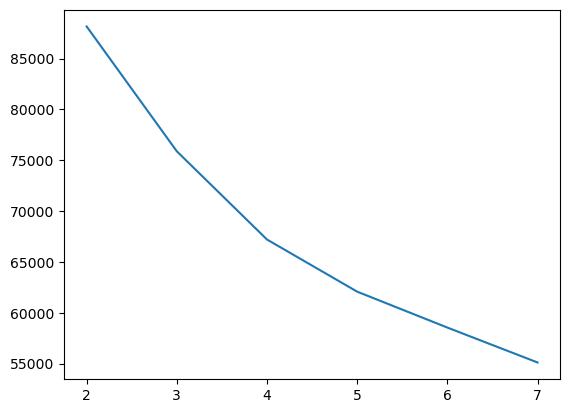

In [88]:
plt.plot(clusters,ssd)

In [89]:
kmodel = KMeans(n_clusters=5, init='k-means++')

In [90]:
kmodel.fit(df)

KMeans(n_clusters=5)

In [91]:
kmodel.labels_

array([4, 3, 1, ..., 4, 2, 4])

In [92]:
from sklearn.metrics import silhouette_score

In [93]:
wcss = kmodel.inertia_

labels = kmodel.labels_
silhouette_avg = silhouette_score(df, labels)

print("WCSS:", wcss)
print("Silhouette Score:", silhouette_avg)

WCSS: 62078.16770747349
Silhouette Score: 0.19001407519037586


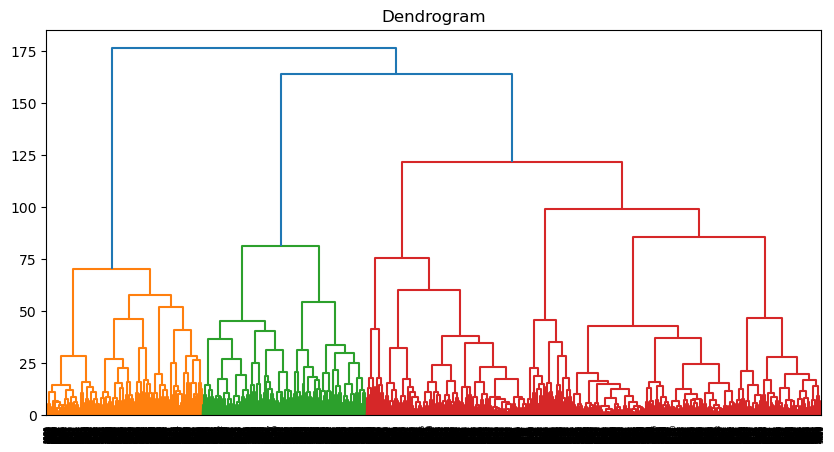

In [78]:
from scipy.cluster.hierarchy import dendrogram, linkage

link = linkage(df.values, 'ward') #complete, average, centroid, mean, single

plt.figure(figsize=(10, 5))
dendrogram(link)
plt.title('Dendrogram')
plt.show()